# Mouse Behavior Pipeline for Bipolar Phase Research

This notebook builds a **research pipeline** from mouse movement logs to behavioral signals.

## Important clinical note
- This is **not a medical diagnosis tool**.
- Outputs are behavioral risk indicators only.
- Any clinical interpretation must be done by qualified professionals.

## Data source options
- Custom browser logger (recommended for raw control): logs `timestamp`, `x`, `y`, `event_type`.

## Expected raw columns
- `timestamp` (datetime or milliseconds)
- `x` (mouse x position)
- `y` (mouse y position)
- `event_type` (for example: `move`, `click`, `scroll`)

In [1]:
# ── Dependencies ─────────────────────────────────────────────────────────────
# Uncomment once to install if running fresh:
# %pip install pandas numpy scikit-learn matplotlib joblib requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial          # used for fast quantile aggregation

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)


In [2]:
from pathlib import Path
from io import StringIO
import requests

# ── Config ───────────────────────────────────────────────────────────────────
DATA_PATH = "mouse_events.csv"          # path to your own CSV (if available)
USE_BALABIT_IF_MISSING = True           # fall back to public Balabit dataset
BALABIT_MAX_USERS = 3                   # how many users to download
BALABIT_SESSIONS_PER_USER = 5          # sessions per user

# Screen-coordinate sanity bounds (pixels).
# Events outside these ranges are almost certainly corrupt log entries.
COORD_X_MIN, COORD_X_MAX = -100, 10_000
COORD_Y_MIN, COORD_Y_MAX = -100,  8_000


def _normalize_schema(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename raw columns to the standard schema (timestamp, x, y, event_type)
    and coerce types.  Drops rows that cannot be parsed.
    """
    # ── 1. Column renaming ───────────────────────────────────────────────────
    rename_map = {}
    for col in raw_df.columns:
        c = col.strip().lower()
        if c in {"time", "ts", "event_time", "datetime", "client_timestamp", "record_timestamp"}:
            rename_map[col] = "timestamp"
        elif c in {"clientx", "pagex", "mouse_x", "posx", "x"}:
            rename_map[col] = "x"
        elif c in {"clienty", "pagey", "mouse_y", "posy", "y"}:
            rename_map[col] = "y"
        elif c in {"type", "event", "action", "state", "event_type"}:
            rename_map[col] = "event_type"
    raw_df = raw_df.rename(columns=rename_map)

    required = {"timestamp", "x", "y"}
    missing = required - set(raw_df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Need at least timestamp, x, y.")

    if "event_type" not in raw_df.columns:
        raw_df["event_type"] = "move"

    # ── 2. Timestamp parsing ─────────────────────────────────────────────────
    # FIX: threshold raised from 1e10 to 1e11.
    # Unix-seconds for year 2023 are ~1_700_000_000 which is > 1e9 but < 1e10,
    # so the old threshold mis-classified them as milliseconds.
    # Millisecond timestamps are > 1e12, so 1e11 is a safe midpoint.
    if np.issubdtype(raw_df["timestamp"].dtype, np.number):
        unit = "ms" if raw_df["timestamp"].median() > 1e11 else "s"
        raw_df["timestamp"] = pd.to_datetime(raw_df["timestamp"], unit=unit, errors="coerce")
    else:
        raw_df["timestamp"] = pd.to_datetime(raw_df["timestamp"], errors="coerce")

    # ── 3. Drop unparseable rows ─────────────────────────────────────────────
    raw_df = (
        raw_df
        .dropna(subset=["timestamp", "x", "y"])
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # ── 4. Coordinate sanity filter ──────────────────────────────────────────
    # Extreme or negative coordinates indicate log corruption; they inflate
    # speed/acceleration and pollute the anomaly model.
    n_before = len(raw_df)
    raw_df = raw_df[
        raw_df["x"].between(COORD_X_MIN, COORD_X_MAX) &
        raw_df["y"].between(COORD_Y_MIN, COORD_Y_MAX)
    ].reset_index(drop=True)
    n_dropped = n_before - len(raw_df)
    if n_dropped:
        print(f"  [coord filter] dropped {n_dropped} out-of-range rows")

    return raw_df


def _is_compatible_local_csv(path: Path) -> bool:
    """Return True if the CSV has the minimum required columns."""
    try:
        cols = set(pd.read_csv(path, nrows=5).columns.str.lower())
    except Exception:
        return False
    has_x = bool(cols & {"x", "clientx", "pagex", "mouse_x", "posx"})
    has_y = bool(cols & {"y", "clienty", "pagey", "mouse_y", "posy"})
    has_t = bool(cols & {"timestamp", "time", "ts", "datetime", "event_time",
                          "client_timestamp", "record_timestamp"})
    return has_x and has_y and has_t


def load_balabit_subset(max_users=3, sessions_per_user=3, timeout=40) -> pd.DataFrame:
    """
    Download a small subset of the public Balabit Mouse-Dynamics dataset from GitHub.
    Timestamps are made monotonically increasing across sessions so the whole
    dataset can be treated as one contiguous timeline per user.
    """
    base_api = "https://api.github.com/repos/balabit/Mouse-Dynamics-Challenge/contents"
    session_cols = ["record_timestamp", "client_timestamp", "button", "state", "x", "y"]
    frames = []

    users_resp = requests.get(f"{base_api}/training_files", timeout=timeout)
    users_resp.raise_for_status()
    users = sorted(
        item["name"] for item in users_resp.json() if item.get("type") == "dir"
    )[:max_users]

    session_offset = 0.0
    for user in users:
        sessions_resp = requests.get(f"{base_api}/training_files/{user}", timeout=timeout)
        sessions_resp.raise_for_status()
        sessions = sorted(
            (s for s in sessions_resp.json() if s.get("type") == "file"),
            key=lambda d: d["name"],
        )[:sessions_per_user]

        for s in sessions:
            text = requests.get(s["download_url"], timeout=timeout).text
            df = pd.read_csv(StringIO(text), header=None, names=session_cols)

            # Build a global monotonic wall-clock: each session starts after the previous.
            t = pd.to_numeric(df["client_timestamp"], errors="coerce").fillna(0.0)
            df["timestamp"] = pd.Timestamp("2020-01-01") + pd.to_timedelta(
                t + session_offset, unit="s"
            )
            session_offset += float(t.max()) + 5.0   # 5-second gap between sessions

            df["event_type"] = df["state"].astype(str).str.lower()
            df["user_id"]    = user
            df["session_id"] = s["name"]
            frames.append(df[["timestamp", "x", "y", "event_type", "user_id", "session_id"]])

    if not frames:
        raise RuntimeError("Balabit download returned no session data.")

    out = pd.concat(frames, ignore_index=True)
    out["x"] = pd.to_numeric(out["x"], errors="coerce")
    out["y"] = pd.to_numeric(out["y"], errors="coerce")
    return out.dropna(subset=["x", "y"]).reset_index(drop=True)


# ── Load data ─────────────────────────────────────────────────────────────────
candidate_paths = [Path(DATA_PATH)] + sorted(Path(".").glob("*.csv"))
compatible = [p for p in candidate_paths if p.exists() and _is_compatible_local_csv(p)]

if compatible:
    data_file = compatible[0]
    print(f"Using local CSV: {data_file}")
    raw = _normalize_schema(pd.read_csv(data_file))
else:
    if not USE_BALABIT_IF_MISSING:
        raise FileNotFoundError(
            "No compatible local CSV found.  Place a mouse event CSV here "
            "or set USE_BALABIT_IF_MISSING = True."
        )
    print("No local CSV found — downloading Balabit dataset subset...")
    raw = _normalize_schema(
        load_balabit_subset(max_users=BALABIT_MAX_USERS, sessions_per_user=BALABIT_SESSIONS_PER_USER)
    )

print(f"Loaded {len(raw):,} rows")
raw.head()


No local CSV found — downloading Balabit dataset subset...
  [coord filter] dropped 6 out-of-range rows
Loaded 520,908 rows


,timestamp,x,y,event_type,user_id,session_id
0,2020-01-01 00:00:00.000,1043.0,410.0,move,user12,session_2144641057
1,2020-01-01 00:00:00.094,1024.0,410.0,move,user12,session_2144641057
2,2020-01-01 00:00:00.094,1019.0,410.0,move,user12,session_2144641057
3,2020-01-01 00:00:00.234,979.0,409.0,move,user12,session_2144641057
4,2020-01-01 00:00:00.234,974.0,411.0,move,user12,session_2144641057


In [3]:
# ── Named aggregation helper (replaces slow lambda) ──────────────────────────
# pandas cannot vectorise an anonymous lambda inside resample().agg();
# it falls back to row-by-row Python iteration.
# A named function avoids that and can be optimised by pandas internally.
def _p95(s: pd.Series) -> float:
    return s.quantile(0.95)


def build_event_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-event kinematic features: speed, acceleration, event flags.

    SESSION-BOUNDARY HANDLING  (critical fix)
    ──────────────────────────────────────────
    diff() across a session or user boundary produces a meaningless large
    delta (last row of session N -> first row of session N+1).
    We group by [user_id, session_id] before calling diff() so deltas are
    always computed within the same continuous recording.
    """
    # ── 1. Determine grouping ────────────────────────────────────────────────
    group_cols = [c for c in ["user_id", "session_id"] if c in df.columns]

    if group_cols:
        g      = df.groupby(group_cols, sort=False)
        dx     = g["x"].diff().fillna(0.0)
        dy     = g["y"].diff().fillna(0.0)
        dt_raw = g["timestamp"].diff().dt.total_seconds().fillna(0.0)
    else:
        dx     = df["x"].diff().fillna(0.0)
        dy     = df["y"].diff().fillna(0.0)
        dt_raw = df["timestamp"].diff().dt.total_seconds().fillna(0.0)

    # ── 2. Kinematic features ────────────────────────────────────────────────
    out       = df.copy()
    out["dx"] = dx
    out["dy"] = dy
    out["dist"] = np.sqrt(dx**2 + dy**2)

    # Clip dt to avoid division-by-zero, but keep the raw value for:
    #   a) is_idle_gap detection (genuine pauses must not be clipped away)
    #   b) zeroing speed/accel at group boundaries (where dt_raw == 0)
    dt_clipped = dt_raw.clip(lower=1e-3)

    # Speed = 0 at the first row of each session (dt_raw == 0 there).
    out["speed"] = (out["dist"] / dt_clipped).where(dt_raw > 0, 0.0)

    # Acceleration: forward-difference of speed / dt, zeroed at boundaries.
    if group_cols:
        speed_diff = (
            df.groupby(group_cols, sort=False)
            .apply(lambda grp: out.loc[grp.index, "speed"].diff())
            .droplevel(list(range(len(group_cols))))
            .reindex(df.index)
            .fillna(0.0)
        )
    else:
        speed_diff = out["speed"].diff().fillna(0.0)

    out["accel"] = (speed_diff / dt_clipped).where(dt_raw > 0, 0.0)

    # ── 3. Event-type flags ──────────────────────────────────────────────────
    etype = out["event_type"].astype(str).str.lower()
    out["is_click"]    = (etype == "click").astype(int)
    out["is_scroll"]   = (etype == "scroll").astype(int)
    # Idle gap: no movement for more than 1.5 s within the same session.
    # Uses un-clipped dt so genuine pauses are correctly identified.
    out["is_idle_gap"] = (dt_raw > 1.5).astype(int)

    return out


def aggregate_windows(df: pd.DataFrame, window: str = "60s") -> pd.DataFrame:
    """
    Resample event rows into fixed-duration time windows and compute summary stats.

    Each output row = one time window (default 60 seconds).

    Features produced:
      speed_mean/std/p95  -- distribution of cursor speed in this window
      accel_mean/std      -- distribution of acceleration
      distance_total      -- total pixels travelled
      event_count         -- number of recorded events
      click_count         -- number of click events
      scroll_count        -- number of scroll events
      idle_ratio          -- fraction of events preceded by a >1.5 s pause
      activity_index      -- composite engagement score in [0, 1]
    """
    tmp = df.set_index("timestamp")
    agg = tmp.resample(window).agg(
        speed_mean     = ("speed",       "mean"),
        speed_std      = ("speed",       "std"),
        speed_p95      = ("speed",       _p95),   # named fn avoids slow lambda
        accel_mean     = ("accel",       "mean"),
        accel_std      = ("accel",       "std"),
        distance_total = ("dist",        "sum"),
        event_count    = ("dist",        "count"),
        click_count    = ("is_click",    "sum"),
        scroll_count   = ("is_scroll",   "sum"),
        idle_ratio     = ("is_idle_gap", "mean"),
    )

    agg = agg.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # ── Activity index ────────────────────────────────────────────────────────
    # FIX: each component is min-max normalised to [0, 1] before weighting.
    # Without normalisation speed_mean (thousands of px/s) would dominate over
    # event_count (tens of events), making the other weights meaningless.
    def _norm(s: pd.Series) -> pd.Series:
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 1e-9 else pd.Series(0.0, index=s.index)

    agg["activity_index"] = (
        0.40 * _norm(agg["speed_mean"])    # average cursor speed
        + 0.25 * _norm(agg["speed_p95"])   # burst speed (top 5 %)
        + 0.20 * _norm(agg["event_count"]) # movement density
        + 0.15 * _norm(agg["click_count"]) # click engagement
    )
    return agg


# ── Run ───────────────────────────────────────────────────────────────────────
features_events = build_event_features(raw)
X = aggregate_windows(features_events, window="60s")

print(f"Event rows   : {len(features_events):,}")
print(f"Time windows : {len(X):,}  (each = 60 s of data)")
X.head()


C:\Users\maale\AppData\Local\Temp\ipykernel_31404\387298733.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: out.loc[grp.index, "speed"].diff())


Event rows   : 520,908
Time windows : 4,042  (each = 60 s of data)


,speed_mean,speed_std,speed_p95,accel_mean,accel_std,distance_total,event_count,click_count,scroll_count,idle_ratio,activity_index
timestamp,,,,,,,,,,,
2020-01-01 00:00:00,328.880080,560.352239,1597.130566,1117.217205,5564.994847,9867.036944,246,0,0,0.020325,0.111023
2020-01-01 00:01:00,194.834504,220.897085,621.291642,329.719739,1992.639471,983.841785,43,0,0,0.000000,0.028474
2020-01-01 00:02:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000
2020-01-01 00:03:00,519.976588,768.400944,1909.379009,1814.369871,9060.091932,3012.278036,49,0,0,0.040816,0.055023
2020-01-01 00:04:00,313.767961,744.912862,1575.355761,748.173360,8433.935213,9017.310868,243,0,0,0.012346,0.109097


In [4]:
# ── Isolation Forest anomaly detector ────────────────────────────────────────
#
# HOW IT WORKS
# ─────────────
# IsolationForest builds an ensemble of random decision trees.
# Points that need fewer splits to isolate are treated as anomalies.
#
# Outputs:
#   predict()           -> +1 (inlier / normal)  or  -1 (outlier / anomaly)
#   decision_function() -> continuous score; LOWER means MORE anomalous;
#                          crosses 0 at the contamination threshold
#
# TRAINING STRATEGY
# ─────────────────
# Ideally train only on known euthymic (baseline) windows so the model
# learns what normal looks like.  If you have labels, filter X:
#   train_X = X[X.index.isin(baseline_window_indices)]
# For now we train unsupervised on all data.

train_X = X.copy()

model = Pipeline(
    steps=[
        # Step 1 – StandardScaler
        # Centres each feature to mean=0, std=1.
        # Required because IsolationForest is sensitive to feature scale;
        # without scaling, high-variance features (e.g. speed) dominate splits.
        ("scaler",  StandardScaler()),

        # Step 2 – IsolationForest
        #   n_estimators  : number of trees (300 gives stable scores; 100 is faster)
        #   contamination : expected fraction of anomalous windows.
        #                   0.15 = we assume ~15 % of windows show dysregulation.
        #                   Increase if your subject is in an active episode.
        ("iforest", IsolationForest(
            n_estimators=300,
            contamination=0.15,
            random_state=42,
        )),
    ]
)

model.fit(train_X)

# ── Predict ───────────────────────────────────────────────────────────────────
# FIX: call predict / decision_function on the Pipeline object directly.
# The Pipeline applies the scaler automatically before passing data to the
# forest — no need to manually chain named_steps["scaler"].transform(X).
pred  = model.predict(X)             # +1 = normal,  -1 = anomaly
score = model.decision_function(X)   # continuous score (lower = more anomalous)

results = X.copy()
results["anomaly_flag"]  = (pred == -1).astype(int)   # 1 if window is anomalous
results["anomaly_score"] = score

# ── Heuristic phase interpretation ───────────────────────────────────────────
# After binary anomaly detection, split anomalous windows into subtypes
# using activity_index (the composite engagement score from aggregation):
#   manic_like      -> anomalous  AND  activity in top 25 %
#   depressed_like  -> anomalous  AND  activity in bottom 25 %
#   anomalous_mixed -> anomalous  AND  activity in middle range
#   normal_like     -> not flagged as anomalous
hi_thr = results["activity_index"].quantile(0.75)
lo_thr = results["activity_index"].quantile(0.25)

conditions = [
    (results["anomaly_flag"] == 0),
    (results["anomaly_flag"] == 1) & (results["activity_index"] >= hi_thr),
    (results["anomaly_flag"] == 1) & (results["activity_index"] <= lo_thr),
]
choices = ["normal_like", "manic_like", "depressed_like"]
results["phase_prediction"] = np.select(conditions, choices, default="anomalous_mixed")

print("Anomaly counts:")
print(results["anomaly_flag"].value_counts().rename({0: "normal", 1: "anomaly"}))
print()
print("Phase prediction counts:")
print(results["phase_prediction"].value_counts())
results[["anomaly_flag", "anomaly_score", "activity_index", "phase_prediction"]].head()


Anomaly counts:
anomaly_flag
normal     3435
anomaly     607
Name: count, dtype: int64

Phase prediction counts:
phase_prediction
normal_like        3435
manic_like          359
anomalous_mixed     248
Name: count, dtype: int64


,anomaly_flag,anomaly_score,activity_index,phase_prediction
timestamp,,,,
2020-01-01 00:00:00,0,0.073358,0.111023,normal_like
2020-01-01 00:01:00,0,0.014045,0.028474,normal_like
2020-01-01 00:02:00,0,0.079735,0.000000,normal_like
2020-01-01 00:03:00,0,0.033757,0.055023,normal_like
2020-01-01 00:04:00,0,0.081006,0.109097,normal_like


## Two-stage supervised classification (anomalies only)

Train a supervised classifier only on windows flagged as anomalous by Isolation Forest.
Add your labels per window into `results["phase_label"]` before running the next cell.

No manual labels found — using heuristic phase_prediction as proxy labels.
              precision    recall  f1-score   support

       manic       0.99      0.99      0.99       108
       mixed       0.99      0.99      0.99        75

    accuracy                           0.99       183
   macro avg       0.99      0.99      0.99       183
weighted avg       0.99      0.99      0.99       183



,anomaly_flag,phase_label,phase_pred_supervised
timestamp,,,
2020-01-01 00:00:00,0,NaN,NaN
2020-01-01 00:01:00,0,NaN,NaN
2020-01-01 00:02:00,0,NaN,NaN
2020-01-01 00:03:00,0,NaN,NaN
2020-01-01 00:04:00,0,NaN,NaN


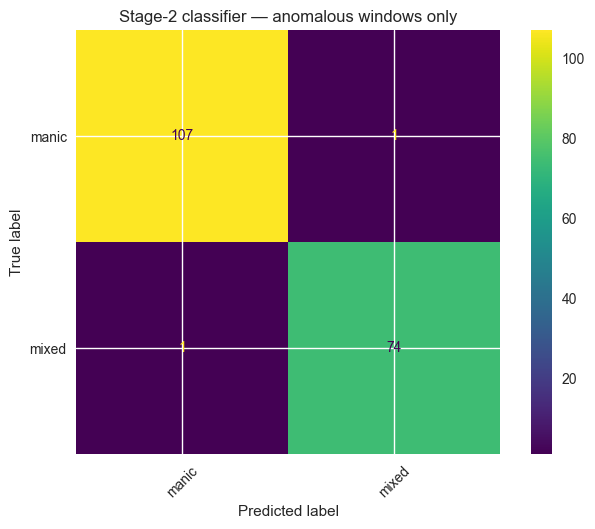

In [5]:
# ── Two-stage supervised classifier (optional) ────────────────────────────────
#
# Stage 1 (Isolation Forest, above) flags windows as anomalous or normal.
# Stage 2 (this cell) trains a supervised model ONLY on anomalous windows
# to distinguish manic vs depressed vs other — but ONLY if you supply labels.
#
# HOW TO PROVIDE LABELS
# ─────────────────────
# Create a CSV with columns [timestamp, label] where:
#   timestamp = window start (floor to minute, matching the index of X)
#   label     = one of {manic, depressed, mixed}
# Then uncomment:
#   labels = pd.read_csv("window_labels.csv", index_col=0, parse_dates=True)["label"]
#   results["phase_label"] = labels.reindex(results.index)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

# Auto-derive phase_label from heuristic phase_prediction if not manually provided.
if "phase_label" not in results.columns:
    label_map = {
        "manic_like":      "manic",
        "depressed_like":  "depressed",
        "anomalous_mixed": "mixed",
    }
    results["phase_label"] = results["phase_prediction"].map(label_map)
    print("No manual labels found — using heuristic phase_prediction as proxy labels.")

# Only train on windows already flagged as anomalous by Isolation Forest —
# normal windows do not need fine-grained phase classification.
anom_mask = results["anomaly_flag"] == 1
if anom_mask.sum() == 0:
    raise ValueError("No anomalous windows detected; cannot train a second-stage classifier.")

X_anom = X.loc[anom_mask]
y_anom = results.loc[anom_mask, "phase_label"].dropna()
X_anom = X_anom.loc[y_anom.index]

if len(X_anom) < 10:
    raise ValueError(f"Only {len(X_anom)} anomalous windows — need >= 10 for reliable training.")
if y_anom.nunique() < 2:
    raise ValueError("Need at least 2 distinct classes in phase_label.")

# 70 / 30 train-test split, stratified to preserve class proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X_anom, y_anom, test_size=0.30, random_state=42, stratify=y_anom
)

clf = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        # class_weight='balanced' compensates for class imbalance
        # (there are typically far fewer depressed windows than manic ones).
        ("clf",    LogisticRegression(max_iter=500, class_weight="balanced")),
    ]
)

clf.fit(X_train, y_train)
pred_test = clf.predict(X_test)

print(classification_report(y_test, pred_test))
disp = ConfusionMatrixDisplay.from_predictions(y_test, pred_test, xticks_rotation=45)
_ = disp.ax_.set_title("Stage-2 classifier — anomalous windows only")

# Write supervised predictions back into results for all anomalous rows.
results.loc[anom_mask, "phase_pred_supervised"] = clf.predict(X_anom)
results[["anomaly_flag", "phase_label", "phase_pred_supervised"]].head()


## Classifier Evaluation Metrics

The cells below measure how well the **Stage-2 logistic classifier** separates behavioral phases on the anomalous windows flagged by Isolation Forest.

| Metric | What it tells you |
|--------|------------------|
| **Train / Test accuracy** | Fraction of windows correctly classified on seen / unseen data |
| **CV accuracy (5-fold)** | More reliable estimate — the model is retrained 5 times on different splits |
| **F1 score** | Harmonic mean of precision & recall — best single headline metric per class |
| **AUC-ROC** | Area under the ROC curve; 1.0 = perfect, 0.5 = random guessing |
| **Feature coefficients** | Which features drive each class prediction and in which direction |

> **Important:** When no manual labels are provided, labels come from the Isolation Forest heuristic.  
> Accuracy then measures internal consistency, **not** clinical validity.

Cross-validation accuracy     : 0.972  ± 0.012
Per-fold scores               : [0.975 0.951 0.983 0.967 0.983]
Train-set accuracy            : 0.988
Test-set  accuracy            : 0.989



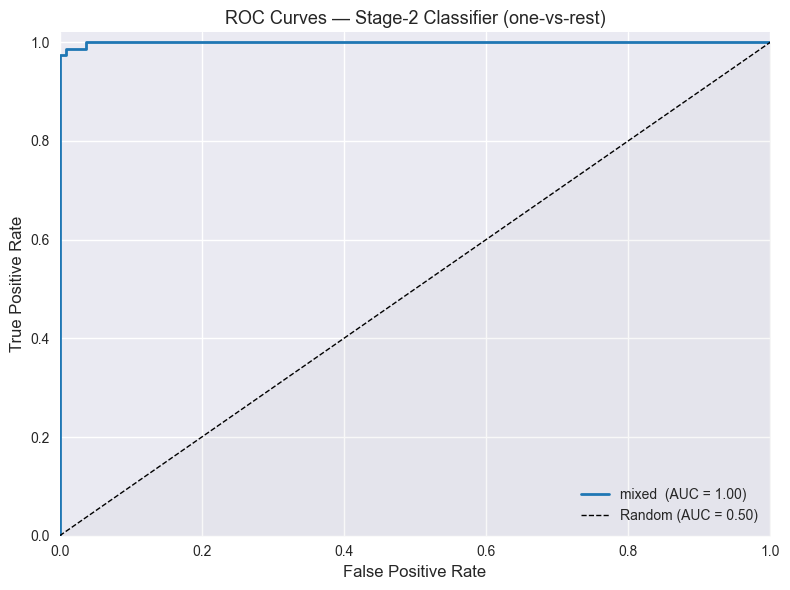

In [6]:
# ── ROC curves + cross-validation accuracy ────────────────────────────────────
if "clf" not in dir():
    print("Supervised classifier not trained — run the cell above first.")
else:
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc
    from sklearn.model_selection import cross_val_score

    _classes = list(clf.named_steps["clf"].classes_)
    n_folds = min(5, len(X_anom) // 2)
    if n_folds >= 2:
        cv_scores = cross_val_score(clf, X_anom, y_anom, cv=n_folds, scoring="accuracy")
        print(f"{'Cross-validation accuracy':30s}: {cv_scores.mean():.3f}  ± {cv_scores.std():.3f}")
        print(f"{'Per-fold scores':30s}: {cv_scores.round(3)}")
    else:
        print("Cross-validation skipped: not enough samples for >=2 folds.")
    print(f"{'Train-set accuracy':30s}: {(clf.predict(X_train) == y_train).mean():.3f}")
    print(f"{'Test-set  accuracy':30s}: {(clf.predict(X_test)  == y_test ).mean():.3f}")
    print()

    y_prob = clf.predict_proba(X_test)
    palette = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]
    fig, ax = plt.subplots(figsize=(8, 6))

    plotted = False
    if len(_classes) == 2:
        # Binary case: plot ROC for the positive class only.
        pos_label = _classes[1]
        y_true = (y_test == pos_label).astype(int)
        if len(np.unique(y_true)) > 1:
            fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=palette[0], lw=2,
                    label=f"{pos_label}  (AUC = {roc_auc:.2f})")
            plotted = True
        else:
            print("ROC curve skipped: test set has only one class.")
    else:
        y_test_bin = label_binarize(y_test, classes=_classes)
        if y_test_bin.ndim == 1:
            y_test_bin = y_test_bin.reshape(-1, 1)
        for i, cls in enumerate(_classes):
            if y_test_bin.shape[1] > i and len(np.unique(y_test_bin[:, i])) > 1:
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, color=palette[i % len(palette)], lw=2,
                        label=f"{cls}  (AUC = {roc_auc:.2f})")
                plotted = True
            else:
                print(f"ROC curve skipped for class '{cls}': only one label in test set.")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")
    ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("ROC Curves — Stage-2 Classifier (one-vs-rest)", fontsize=13)
    if plotted:
        ax.legend(fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout()
    plt.show()


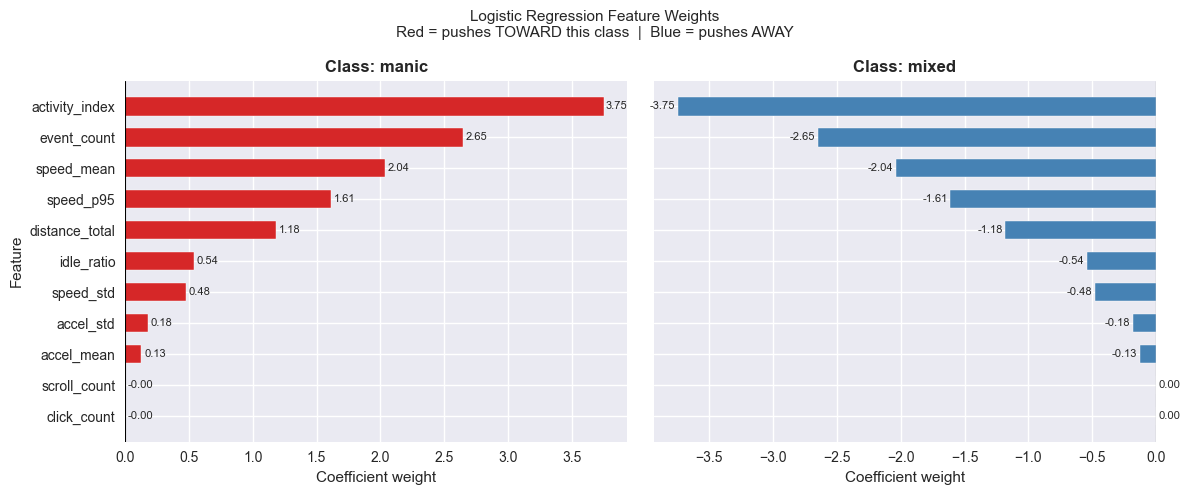


Coefficient table:


,manic,mixed
speed_mean,2.039,-2.039
speed_std,0.477,-0.477
speed_p95,1.614,-1.614
accel_mean,0.128,-0.128
accel_std,0.179,-0.179
distance_total,1.181,-1.181
event_count,2.648,-2.648
click_count,-0.000,0.000
scroll_count,-0.000,0.000
idle_ratio,0.541,-0.541


In [7]:
# ── Feature importance: logistic regression coefficients ─────────────────────
if "clf" not in dir():
    print("Supervised classifier not trained — run the cell above first.")
else:
    _feat_cols = [
        "speed_mean", "speed_std", "speed_p95", "accel_mean", "accel_std",
        "distance_total", "event_count", "click_count", "scroll_count",
        "idle_ratio", "activity_index",
    ]
    # Align coefficient rows with sklearn's class ordering.
    _classes = list(clf.named_steps["clf"].classes_)
    coef_raw = clf.named_steps["clf"].coef_
    if coef_raw.shape[0] == 1 and len(_classes) == 2:
        # Binary case: sklearn stores weights for the positive class only.
        coef_rows = np.vstack([-coef_raw, coef_raw])
    else:
        coef_rows = coef_raw
    coef_df = pd.DataFrame(
        coef_rows,
        index=_classes,
        columns=_feat_cols,
    )

    n_cls = len(_classes)
    fig, axes = plt.subplots(1, n_cls, figsize=(6 * n_cls, 5), sharey=True)
    if n_cls == 1:
        axes = [axes]

    for ax, cls in zip(axes, _classes):
        vals = coef_df.loc[cls].sort_values()
        bar_colors = ["tab:red" if v > 0 else "steelblue" for v in vals]
        bars = ax.barh(vals.index, vals.values, color=bar_colors, edgecolor="white", height=0.6)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(f"Class: {cls}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Coefficient weight")
        for bar, v in zip(bars, vals.values):
            ax.text(
                v + (0.02 if v >= 0 else -0.02),
                bar.get_y() + bar.get_height() / 2,
                f"{v:.2f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8,
            )

    axes[0].set_ylabel("Feature")
    fig.suptitle(
        "Logistic Regression Feature Weights\n"
        "Red = pushes TOWARD this class  |  Blue = pushes AWAY",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

    print("\nCoefficient table:")
    display(
        coef_df.T
        .style.background_gradient(cmap="RdBu_r", axis=None)
        .format("{:.3f}")
        .set_caption("Feature coefficients per class (higher = stronger driver for that class)")
    )


In [8]:
# ── Continuous movement dysregulation score ───────────────────────────────────
#
# We combine two normalised signals into a single [0, 1] score:
#
#   anomaly_strength  -- how anomalous is the window (from Isolation Forest).
#                        Derived by inverting and normalising decision_function.
#
#   activity_signed   -- how far above/below the median activity level
#                        the window sits, expressed in IQR units.
#
# SCORE FORMULA
# ─────────────
#   movement_score = 0.65 x anomaly_strength + 0.35 x |activity_signed| / 3
#
#   0  = perfectly normal, calm behaviour
#   1  = strongly anomalous AND highly deviant activity
#
# STATE LABELS
# ────────────
#   normal    -- anomaly_flag = 0  (Isolation Forest inlier)
#   manic     -- anomaly_flag = 1  AND  manic_tendency >= depressed_tendency
#   depressed -- anomaly_flag = 1  AND  depressed_tendency > manic_tendency

# ── 1. Anomaly strength normalised to [0, 1] ──────────────────────────────────
# decision_function is LOWER for more anomalous windows, so we invert it
# so that anomaly_strength = 1 means maximally anomalous.
score_min = results["anomaly_score"].min()
score_max = results["anomaly_score"].max()
anomaly_strength = (score_max - results["anomaly_score"]) / (score_max - score_min + 1e-9)
anomaly_strength = anomaly_strength.clip(0, 1)

# ── 2. Signed activity deviation (IQR units, clipped to +/-3) ────────────────
# Positive = more active than median (manic direction).
# Negative = less active than median (depressed direction).
# Clipping at +/-3 limits the influence of extreme outliers.
act_q25 = results["activity_index"].quantile(0.25)
act_q50 = results["activity_index"].quantile(0.50)   # median baseline
act_q75 = results["activity_index"].quantile(0.75)
iqr = max(act_q75 - act_q25, 1e-9)

activity_signed = ((results["activity_index"] - act_q50) / iqr).clip(-3, 3)

# ── 3. Directional tendency scores ───────────────────────────────────────────
# Linearly map activity_signed from [-3, +3] to [0, 1]:
#   manic_tendency = 1 when activity_signed = +3 (maximum hyperactivity)
#   depressed_tendency = 1 when activity_signed = -3 (maximum hypoactivity)
manic_tendency     = np.clip((activity_signed + 3) / 6, 0, 1)
depressed_tendency = np.clip((-activity_signed + 3) / 6, 0, 1)

# ── 4. Composite score ────────────────────────────────────────────────────────
results["movement_score"] = np.clip(
    0.65 * anomaly_strength + 0.35 * np.abs(activity_signed) / 3,
    0, 1,
)

# ── 5. 3-state label ──────────────────────────────────────────────────────────
results["movement_state"] = np.where(
    results["anomaly_flag"] == 0,
    "normal",
    np.where(manic_tendency >= depressed_tendency, "manic", "depressed"),
)

# ── 6. Ordinal severity level ─────────────────────────────────────────────────
results["movement_level"] = pd.cut(
    results["movement_score"],
    bins   = [0.00, 0.25, 0.50, 0.70, 1.01],
    labels = ["Low", "Mild", "Moderate", "High"],
)

# ── Session-level summary ─────────────────────────────────────────────────────
session_state = results["movement_state"].value_counts().idxmax()
session_score = float(results["movement_score"].mean())

print("Window-level movement state counts:")
print(results["movement_state"].value_counts())
print("\nMovement level counts:")
print(results["movement_level"].value_counts(dropna=False))
print(f"\nSession movement state : {session_state}")
print(f"Session movement score  : {session_score:.3f}  (mean across all windows)")

results[[
    "activity_index", "anomaly_score",
    "movement_score", "movement_state", "movement_level",
]].head()


Window-level movement state counts:
movement_state
normal       3435
manic         481
depressed     126
Name: count, dtype: int64

Movement level counts:
movement_level
Low         3658
Mild         302
Moderate      72
High          10
Name: count, dtype: int64

Session movement state : normal
Session movement score  : 0.123  (mean across all windows)


,activity_index,anomaly_score,movement_score,movement_state,movement_level
timestamp,,,,,
2020-01-01 00:00:00,0.111023,0.073358,0.058904,normal,Low
2020-01-01 00:01:00,0.028474,0.014045,0.150115,normal,Low
2020-01-01 00:02:00,0.000000,0.079735,0.085444,normal,Low
2020-01-01 00:03:00,0.055023,0.033757,0.094823,normal,Low
2020-01-01 00:04:00,0.109097,0.081006,0.046014,normal,Low


## 6. Movement State Scoring

This section converts anomaly + activity features into:
- `movement_state` in `{normal, manic, depressed}`
- `movement_score` in `[0,1]` (higher = stronger dysregulation)
- `movement_level` in `{Low, Mild, Moderate, High}`

Scoring intuition:
- High anomaly + high activity -> manic tendency
- High anomaly + low activity -> depressed tendency
- Low anomaly -> normal tendency

Heuristic phase labels (Isolation Forest + activity threshold):
phase_prediction
normal_like        3435
manic_like          359
anomalous_mixed     248
Name: count, dtype: int64

Movement states (continuous scoring):
movement_state
normal       3435
manic         481
depressed     126
Name: count, dtype: int64

Movement level distribution:
movement_level
Low         3658
Mild         302
Moderate      72
High          10
Name: count, dtype: int64

Overall session state : normal
Overall session score : 0.123


,speed_mean,speed_std,speed_p95,accel_mean,accel_std,distance_total,event_count,click_count,scroll_count,idle_ratio,activity_index,anomaly_flag,anomaly_score,phase_prediction,phase_label,phase_pred_supervised,movement_score,movement_state,movement_level
timestamp,,,,,,,,,,,,,,,,,,,
2020-01-03 19:12:00,487.309245,983.744640,2001.371582,1274.129216,11004.143006,26253.589855,413,0,0,0.002421,0.178834,1,-0.011847,manic_like,manic,manic,0.249900,manic,Low
2020-01-03 19:13:00,1082.451885,3431.179998,5046.928532,13908.130995,195277.910116,42276.335017,241,0,0,0.012448,0.169005,1,-0.179511,manic_like,manic,manic,0.479232,manic,Mild
2020-01-03 19:14:00,491.697246,781.247698,2120.635891,707.735279,8089.201375,13442.906662,240,0,0,0.016667,0.120460,0,0.073133,normal_like,NaN,NaN,0.068876,normal,Low
2020-01-03 19:15:00,570.463756,1265.038383,2481.670646,1580.033549,14623.550170,36458.483609,423,0,0,0.004728,0.189481,1,-0.055500,manic_like,manic,manic,0.323115,manic,Mild
2020-01-03 19:16:00,340.506925,592.822695,1621.195749,697.919140,6473.732459,13159.723471,344,0,0,0.017442,0.145379,0,0.046765,normal_like,NaN,NaN,0.132005,normal,Low
2020-01-03 19:17:00,365.979854,869.774883,1581.673464,814.856200,7017.520756,13742.980244,301,0,0,0.006645,0.131658,0,0.067226,normal_like,NaN,NaN,0.088761,normal,Low
2020-01-03 19:18:00,430.550616,1168.706228,1361.088934,1009.827726,8439.502808,10090.682491,172,0,0,0.005814,0.089255,0,0.068839,normal_like,NaN,NaN,0.043095,normal,Low
2020-01-03 19:19:00,297.910558,750.037681,1316.921268,789.761778,7163.365062,12260.038296,301,0,0,0.016611,0.126563,0,0.066536,normal_like,NaN,NaN,0.084535,normal,Low
2020-01-03 19:20:00,360.567707,720.894281,1553.159485,1201.017639,6977.439659,8706.274247,206,0,0,0.024272,0.098616,0,0.078510,normal_like,NaN,NaN,0.038860,normal,Low


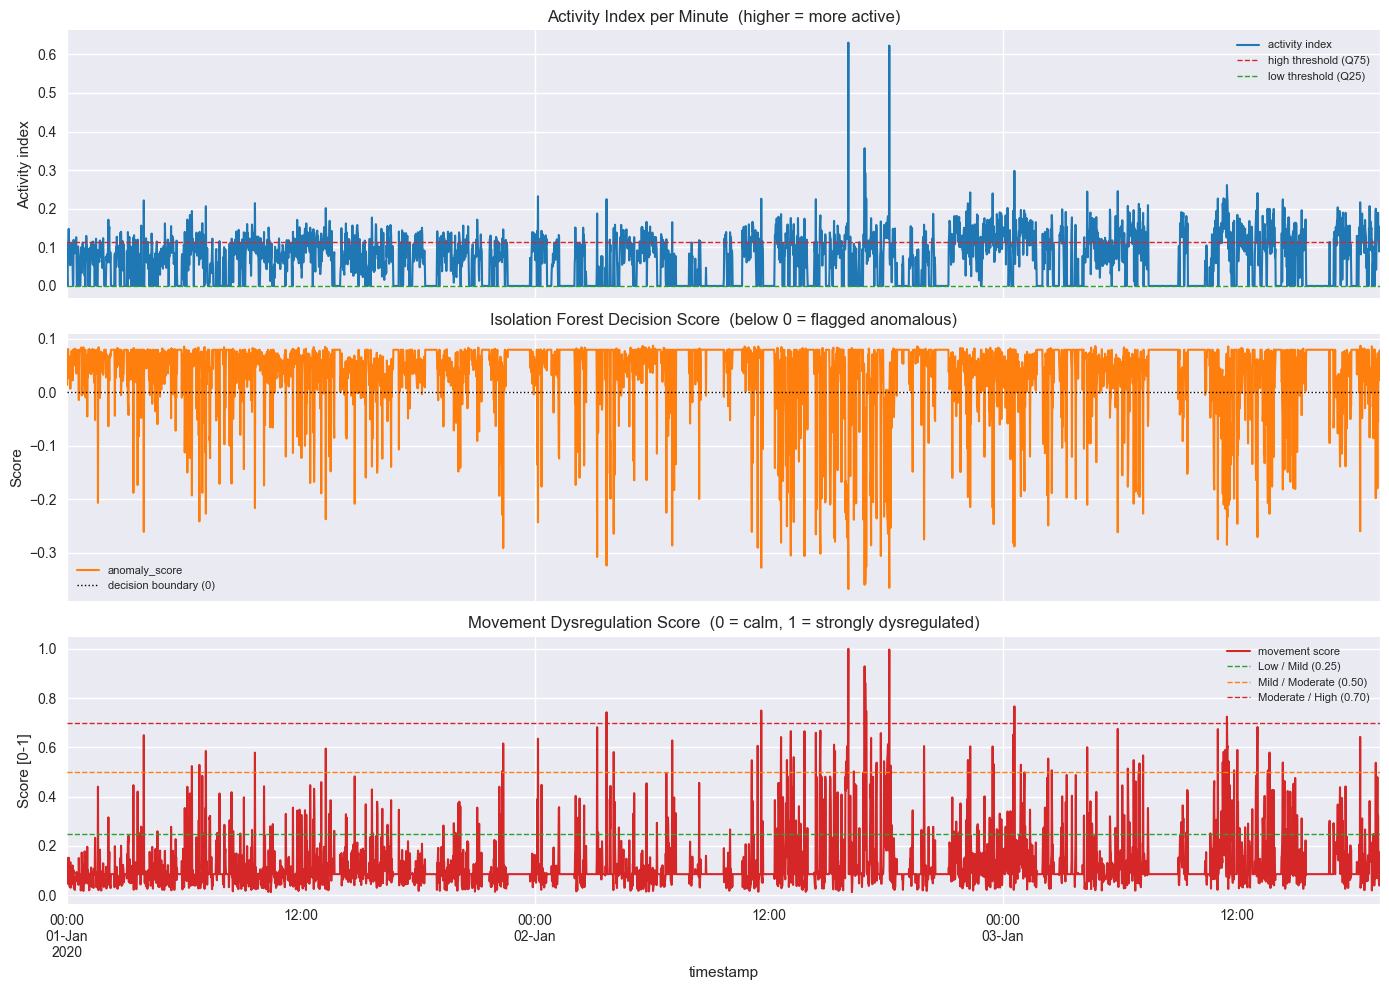

Saved: mouse_phase_predictions.csv


In [9]:
# ── Summary ───────────────────────────────────────────────────────────────────
print("Heuristic phase labels (Isolation Forest + activity threshold):")
print(results["phase_prediction"].value_counts(dropna=False))
print("\nMovement states (continuous scoring):")
print(results["movement_state"].value_counts(dropna=False))
print("\nMovement level distribution:")
print(results["movement_level"].value_counts(dropna=False))

session_state = results["movement_state"].value_counts().idxmax()
session_score = float(results["movement_score"].mean())
print(f"\nOverall session state : {session_state}")
print(f"Overall session score : {session_score:.3f}")

display(results.tail(10))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 – Activity index
# Shows how engaged/active the user is each minute.
# Dashed lines = Q25/Q75 thresholds used to classify manic vs depressed.
results["activity_index"].plot(ax=axes[0], color="tab:blue", lw=1.5, label="activity index")
axes[0].axhline(results["activity_index"].quantile(0.75), color="tab:red",
                ls="--", lw=1, label="high threshold (Q75)")
axes[0].axhline(results["activity_index"].quantile(0.25), color="tab:green",
                ls="--", lw=1, label="low threshold (Q25)")
axes[0].set_title("Activity Index per Minute  (higher = more active)")
axes[0].set_ylabel("Activity index")
axes[0].legend(fontsize=8)

# Panel 2 – Isolation Forest decision score
# Dotted line at 0 = the contamination decision boundary.
# Windows below 0 are flagged as anomalous.
results["anomaly_score"].plot(ax=axes[1], color="tab:orange", lw=1.5)
axes[1].axhline(0, color="black", ls=":", lw=1, label="decision boundary (0)")
axes[1].set_title("Isolation Forest Decision Score  (below 0 = flagged anomalous)")
axes[1].set_ylabel("Score")
axes[1].legend(fontsize=8)

# Panel 3 – Movement score
# Final composite signal combining anomaly strength + activity deviation.
# Horizontal lines mark the Low/Mild/Moderate/High severity boundaries.
results["movement_score"].plot(ax=axes[2], color="tab:red", lw=1.5, label="movement score")
axes[2].axhline(0.25, color="tab:green",  ls="--", lw=1, label="Low / Mild (0.25)")
axes[2].axhline(0.50, color="tab:orange", ls="--", lw=1, label="Mild / Moderate (0.50)")
axes[2].axhline(0.70, color="tab:red",    ls="--", lw=1, label="Moderate / High (0.70)")
axes[2].set_title("Movement Dysregulation Score  (0 = calm, 1 = strongly dysregulated)")
axes[2].set_ylabel("Score [0-1]")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
results.to_csv("mouse_phase_predictions.csv")
print("Saved: mouse_phase_predictions.csv")


In [10]:
# ── Color-coded results table (last 30 windows) ───────────────────────────────
_view_cols = [
    "speed_mean", "speed_p95", "event_count", "idle_ratio",
    "activity_index", "anomaly_score", "movement_score",
    "movement_state", "movement_level",
]
_view = results[_view_cols].tail(30).copy()

def _bg_state(val):
    return {
        "normal":    "background-color: #d4edda; color: #155724",
        "manic":     "background-color: #f8d7da; color: #721c24",
        "depressed": "background-color: #cce5ff; color: #004085",
    }.get(str(val), "")

def _bg_level(val):
    return {
        "Low":      "background-color: #d4edda",
        "Mild":     "background-color: #fff3cd",
        "Moderate": "background-color: #ffd5a8",
        "High":     "background-color: #f8d7da",
    }.get(str(val), "")

display(
    _view.style
    .map(_bg_state,  subset=["movement_state"])
    .map(_bg_level,  subset=["movement_level"])
    .background_gradient(subset=["movement_score"], cmap="Reds",  vmin=0, vmax=1)
    .background_gradient(subset=["activity_index"], cmap="Blues", vmin=0, vmax=1)
    .format({
        "speed_mean":     "{:.1f}",
        "speed_p95":      "{:.1f}",
        "event_count":    "{:.0f}",
        "idle_ratio":     "{:.3f}",
        "activity_index": "{:.3f}",
        "anomaly_score":  "{:.4f}",
        "movement_score": "{:.3f}",
    })
    .set_caption(
        "Last 30 time windows — "
        "Green = normal  |  Red = manic-like  |  Blue = depressed-like"
    )
)


,speed_mean,speed_p95,event_count,idle_ratio,activity_index,anomaly_score,movement_score,movement_state,movement_level
timestamp,,,,,,,,,
2020-01-03 18:52:00,340.2,1758.8,404,0.010,0.167,0.0230,0.188,normal,Low
2020-01-03 18:53:00,213.7,913.2,420,0.012,0.161,0.0004,0.214,normal,Low
2020-01-03 18:54:00,358.2,1704.4,346,0.006,0.147,0.0465,0.135,normal,Low
2020-01-03 18:55:00,431.8,1813.7,338,0.009,0.149,0.0465,0.136,normal,Low
2020-01-03 18:56:00,321.5,1383.5,190,0.011,0.090,0.0860,0.019,normal,Low
2020-01-03 18:57:00,365.9,1892.9,253,0.004,0.117,0.0718,0.067,normal,Low
2020-01-03 18:58:00,0.0,0.0,0,0.000,0.000,0.0797,0.085,normal,Low
2020-01-03 18:59:00,337.6,1425.6,99,0.010,0.060,0.0567,0.057,normal,Low
2020-01-03 19:00:00,446.4,1675.7,82,0.012,0.061,0.0592,0.052,normal,Low


In [11]:
# ── Plain-language session scorecard ─────────────────────────────────────────
_total     = len(results)
_n_normal  = (results["movement_state"] == "normal").sum()
_n_manic   = (results["movement_state"] == "manic").sum()
_n_depressed = (results["movement_state"] == "depressed").sum()
_n_low     = (results["movement_level"] == "Low").sum()
_n_mild    = (results["movement_level"] == "Mild").sum()
_n_mod     = (results["movement_level"] == "Moderate").sum()
_n_high    = (results["movement_level"] == "High").sum()

_mean_score = results["movement_score"].mean()
_max_score  = results["movement_score"].max()
_pct_anom   = 100 * results["anomaly_flag"].mean()
_session_hrs = (results.index[-1] - results.index[0]).total_seconds() / 3600

_overall = results["movement_state"].value_counts().idxmax()
_verdict = {
    "normal":    "Calm / baseline behaviour — no strong dysregulation signal",
    "manic":     "Hyperactive pattern — elevated speed and engagement",
    "depressed": "Hypoactive pattern — low movement and engagement",
}

_bar = "=" * 56
print(_bar)
print("   MOUSE BEHAVIOR ANALYSIS — SESSION SCORECARD")
print(_bar)
print(f"   Session duration        : {_session_hrs:.1f} h")
print(f"   Time windows analysed   : {_total:,}  (1 min each)")
print(f"   Windows flagged anomaly : {results['anomaly_flag'].sum():,}  ({_pct_anom:.1f} %)")
print(_bar)
print(f"   OVERALL STATE  : {_overall.upper()}")
print(f"   → {_verdict[_overall]}")
print(f"   Mean dysregulation score : {_mean_score:.3f}   (0 = calm, 1 = max)")
print(f"   Peak dysregulation score : {_max_score:.3f}")
print(_bar)
print("   WINDOW BREAKDOWN BY STATE")
print(f"     Normal     : {_n_normal:>6,}  ({100*_n_normal/_total:5.1f} %)")
print(f"     Manic      : {_n_manic:>6,}  ({100*_n_manic/_total:5.1f} %)")
print(f"     Depressed  : {_n_depressed:>6,}  ({100*_n_depressed/_total:5.1f} %)")
print(_bar)
print("   WINDOW BREAKDOWN BY SEVERITY LEVEL")
print(f"     Low        : {_n_low:>6,}  ({100*_n_low/_total:5.1f} %)")
print(f"     Mild       : {_n_mild:>6,}  ({100*_n_mild/_total:5.1f} %)")
print(f"     Moderate   : {_n_mod:>6,}  ({100*_n_mod/_total:5.1f} %)")
print(f"     High       : {_n_high:>6,}  ({100*_n_high/_total:5.1f} %)")
print(_bar)
print("   !! Research / behavioral indicator only.")
print("      Not a clinical diagnosis. Consult a qualified professional.")
print(_bar)


   MOUSE BEHAVIOR ANALYSIS — SESSION SCORECARD
   Session duration        : 67.3 h
   Time windows analysed   : 4,042  (1 min each)
   Windows flagged anomaly : 607  (15.0 %)
   OVERALL STATE  : NORMAL
   → Calm / baseline behaviour — no strong dysregulation signal
   Mean dysregulation score : 0.123   (0 = calm, 1 = max)
   Peak dysregulation score : 1.000
   WINDOW BREAKDOWN BY STATE
     Normal     :  3,435  ( 85.0 %)
     Manic      :    481  ( 11.9 %)
     Depressed  :    126  (  3.1 %)
   WINDOW BREAKDOWN BY SEVERITY LEVEL
     Low        :  3,658  ( 90.5 %)
     Mild       :    302  (  7.5 %)
     Moderate   :     72  (  1.8 %)
     High       :     10  (  0.2 %)
   !! Research / behavioral indicator only.
      Not a clinical diagnosis. Consult a qualified professional.


In [12]:
# ── Export model bundle for the backend API ──────────────────────────────────
#
# Everything the backend needs to reproduce notebook predictions is saved in
# one joblib file.  The bundle contains:
#
#   feature_order  -- list of column names the model was trained on.
#                     The API must produce exactly these columns in this order.
#   scaler         -- fitted StandardScaler (apply FIRST, before IsolationForest)
#   iforest        -- fitted IsolationForest
#   score_min/max  -- range used to normalise anomaly_strength to [0, 1]
#   act_q25/50/75  -- activity quartiles used to compute activity_signed

from pathlib import Path
import joblib

feature_order = [
    "speed_mean", "speed_std", "speed_p95", "accel_mean", "accel_std",
    "distance_total", "event_count", "click_count", "scroll_count",
    "idle_ratio", "activity_index",
]

bundle = {
    "feature_order": feature_order,
    "scaler":        model.named_steps["scaler"],
    "iforest":       model.named_steps["iforest"],
    "score_min":     float(results["anomaly_score"].min()),
    "score_max":     float(results["anomaly_score"].max()),
    "act_q25":       float(results["activity_index"].quantile(0.25)),
    "act_q50":       float(results["activity_index"].quantile(0.50)),
    "act_q75":       float(results["activity_index"].quantile(0.75)),
}

out_path = Path("backend/model_artifacts/mouse_iforest_bundle.joblib")
out_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(bundle, out_path)
print("Saved bundle :", out_path.resolve())
print("Bundle keys  :", list(bundle.keys()))


Saved bundle : C:\Users\maale\OneDrive\Desktop\PI_IA\!notebook_finale\backend\model_artifacts\mouse_iforest_bundle.joblib
Bundle keys  : ['feature_order', 'scaler', 'iforest', 'score_min', 'score_max', 'act_q25', 'act_q50', 'act_q75']


## Export Notebook Model Bundle for HTML API

Run the next cell after training to export the exact notebook Isolation Forest model used by the backend API.